7.699999999999999 26.5 46.45 47.75 82.2 103.6 107.7
(100,) (100,)


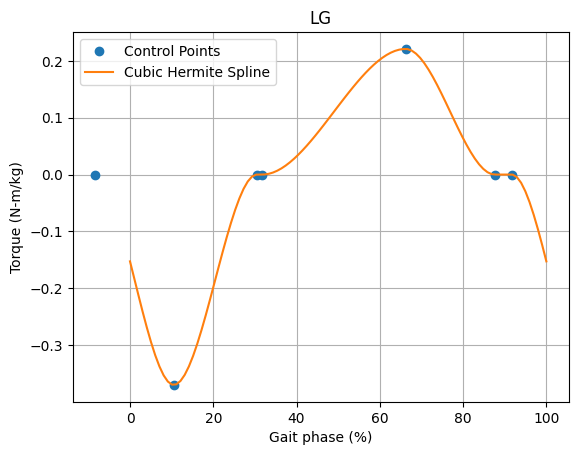

8.8 26.8 47.0 47.599999999999994 83.5 103.9 108.8
(100,) (100,)


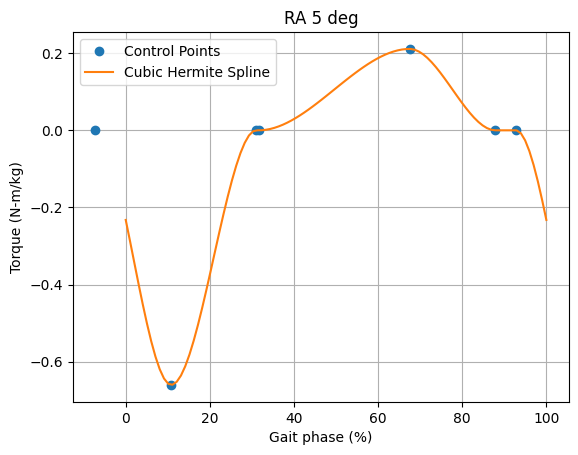

8.8 26.3 48.2 49.2 83.8 104.8 108.8
(100,) (100,)


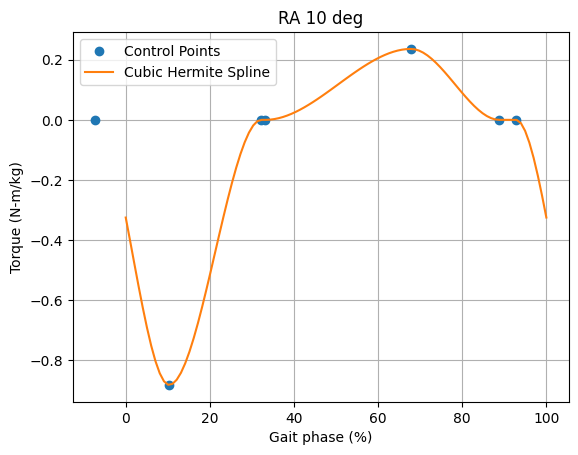

7.699999999999999 26.5 49.45 50.75 82.2 103.6 107.7
(100,) (100,)


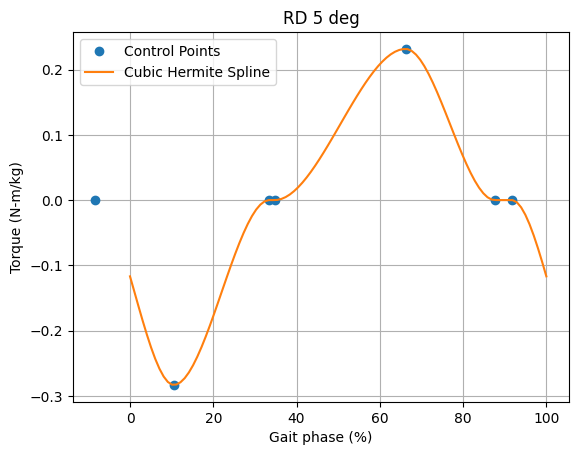

4.699999999999999 23.5 49.45 50.75 80.2 101.6 104.7
(100,) (100,)


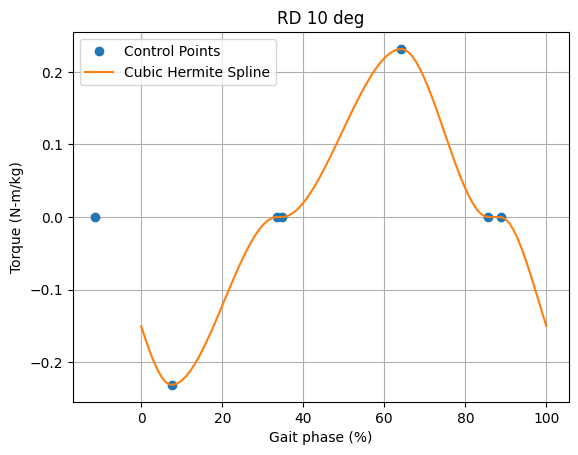

In [6]:
import numpy as np
from scipy.interpolate import CubicHermiteSpline
import pandas as pd
import pickle

inclinations_all = ['RD_10deg', 'RD_5deg', 'LG', 'RA_5deg', 'RA_10deg']
speeds_all = ['0p2mps', '0p4mps', '0p6mps', '0p8mps', '1p0mps', '1p2mps', '1p4mps']

inclinations_val = [-10, -5, 0, 5, 10]
speeds_val = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4]
speeds_val_incline = [0.4, 0.6, 0.8, 1.0]

torque_splines = {inc: {spd: None for spd in speeds_val} for inc in inclinations_val}

class Spline:
    def __init__(self, peak_time, rise_time, mid_time, mid_dur, peak_time_2, fall_time,
                 gp_offset,
                 peak_extension_torque, peak_flexion_torque):

        print(peak_time-rise_time, peak_time, mid_time - mid_dur/2, mid_time + mid_dur/2, peak_time_2, peak_time_2+fall_time, 100+peak_time-rise_time)

        self.spline_x = np.array([peak_time-rise_time-gp_offset, peak_time-gp_offset, mid_time-mid_dur/2-gp_offset, mid_time+mid_dur/2-gp_offset, peak_time_2-gp_offset, peak_time_2+fall_time-gp_offset, 100+peak_time-rise_time-gp_offset])
        self.spline_x = self.spline_x
        self.spline_y = np.array([0.0, peak_extension_torque, 0.0, 0.0, peak_flexion_torque, 0.0, 0.0])
        self.spline_dydx = np.array([0, 0.0, 0.0, 0, 0.0, 0.0, 0])
        self.spline_profile = CubicHermiteSpline(self.spline_x,
                                               self.spline_y,
                                               self.spline_dydx, extrapolate='periodic')

    def plot_spline(self, title):
        import matplotlib.pyplot as plt

        self.x = np.linspace(0, 100, 100)
        self.y = self.spline_profile(self.x)
        print(self.x.shape, self.y.shape)

        plt.plot(self.spline_x, self.spline_y, 'o', label='Control Points')
        plt.plot(self.x, self.y, label='Cubic Hermite Spline')
        plt.title(title)
        plt.xlabel('Gait phase (%)')
        plt.ylabel('Torque (N-m/kg)')
        plt.legend()
        plt.grid()
        plt.show()

    def save_spline_LG(self):
        ref_speed = 1.25  # m/s
        for speed in speeds_val:
            torque_splines[0][speed] = self.y * speed / ref_speed

    def save_spline_RA_5deg(self):
        ref_speed = 1.25 # m/s
        for speed in speeds_val_incline:
            torque_splines[5][speed] = self.y * speed / ref_speed

    def save_spline_RA_10deg(self):
        ref_speed = 1.00 # m/s
        for speed in speeds_val_incline:
            torque_splines[10][speed] = self.y * speed / ref_speed

    def save_spline_RD_5deg(self):
        ref_speed = 1.00 # m/s
        for speed in speeds_val:
            torque_splines[-5][speed] = self.y * speed / ref_speed

    def save_spline_RD_10deg(self):
        ref_speed = 1.00 # m/s
        for speed in speeds_val:
            torque_splines[-10][speed] = self.y * speed / ref_speed

LG_points = [0, 34, 56, 76, 100]
LG_magnitudes = [0.543, -0.456]
RD_5deg_points = [0, 37, 56, 70, 100]
RD_5deg_magnitudes = [0.569, -0.349]
RD_10deg_points = [-3, 37, 54, 65, 97]
RD_10deg_magnitudes = [0.569, -0.285]

RD_5deg_diff = (np.array(RD_5deg_points) - np.array(LG_points))
RD_10deg_diff = (np.array(RD_10deg_points) - np.array(LG_points))
RD_5deg_div = (np.array(RD_5deg_magnitudes) / np.array(LG_magnitudes))
RD_10deg_div = (np.array(RD_10deg_magnitudes) / np.array(LG_magnitudes))

# LG
spline = Spline(
        peak_time = 26.5, rise_time = 18.8, mid_time = 47.1, mid_dur = 1.3, peak_time_2 = 82.2, fall_time = 21.4,
        gp_offset = 16, peak_extension_torque = -0.370, peak_flexion_torque = 0.221
        )
spline.plot_spline(title = 'LG')
spline.save_spline_LG()

# RA_5deg
spline = Spline(
        peak_time = 26.8, rise_time = 18.0, mid_time = 47.3, mid_dur = 0.6, peak_time_2 = 83.5, fall_time = 20.4,
        gp_offset = 16, peak_extension_torque = -0.660, peak_flexion_torque = 0.211
        )
spline.plot_spline(title = 'RA 5 deg')
spline.save_spline_RA_5deg()

# RA_10deg
spline = Spline(
        peak_time = 26.3, rise_time = 17.5, mid_time = 48.7, mid_dur = 1.0, peak_time_2 = 83.8, fall_time = 21.0,
        gp_offset = 16, peak_extension_torque = -0.882, peak_flexion_torque = 0.236
        )
spline.plot_spline(title = 'RA 10 deg')
spline.save_spline_RA_10deg()

# RD_5deg
spline = Spline(
        peak_time = 26.5 + RD_5deg_diff[0], rise_time = 18.8, mid_time = 47.1 + RD_5deg_diff[1], mid_dur = 1.3, peak_time_2 = 82.2 + RD_5deg_diff[2], fall_time = 21.4,
        gp_offset = 16, peak_extension_torque = -0.370 * RD_5deg_div[1], peak_flexion_torque = 0.221 * RD_5deg_div[0]
        )
spline.plot_spline(title = 'RD 5 deg')
spline.save_spline_RD_5deg()

# RD_10deg
spline = Spline(
        peak_time = 26.5 + RD_10deg_diff[0], rise_time = 18.8, mid_time = 47.1 + RD_10deg_diff[1], mid_dur = 1.3, peak_time_2 = 82.2 + RD_10deg_diff[2], fall_time = 21.4,
        gp_offset = 16, peak_extension_torque = -0.370 * RD_10deg_div[1], peak_flexion_torque = 0.221 * RD_10deg_div[0]
        )
spline.plot_spline(title = 'RD 10 deg')
spline.save_spline_RD_10deg()


/tmp/ipykernel_271433/3769529992.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('copper', num_speeds)  # You can choose other colormaps like 'jet', 'plasma', etc.


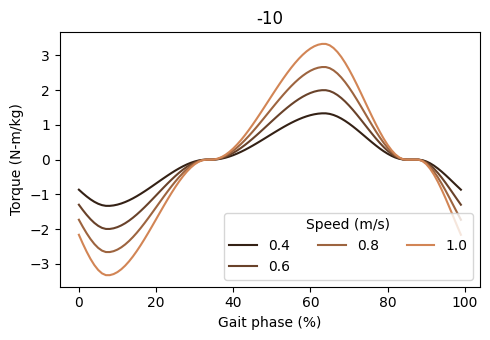

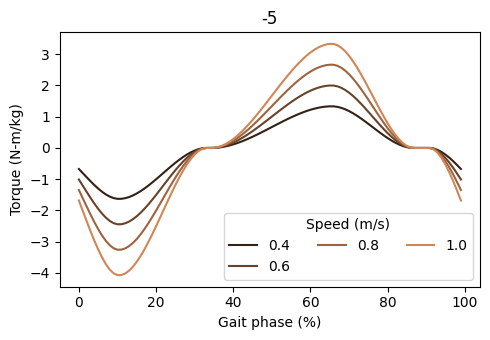

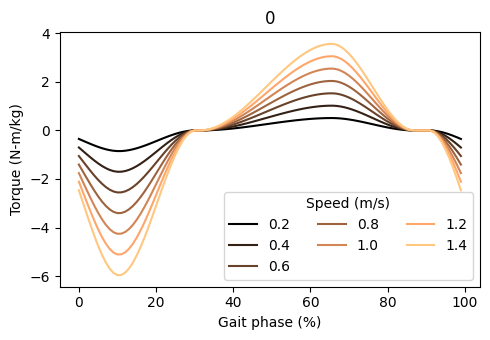

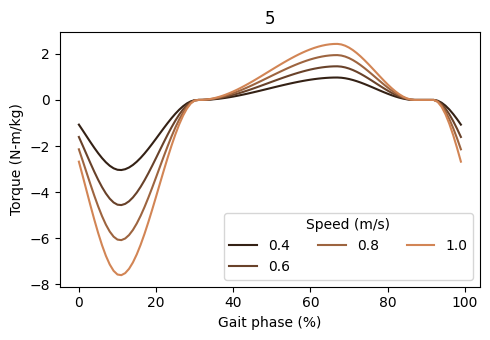

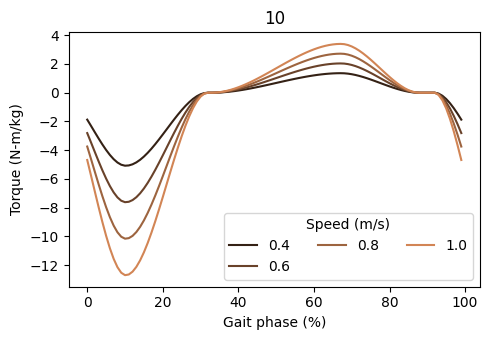

In [25]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as cm

num_speeds = len(speeds_val)
colormap = cm.get_cmap('copper', num_speeds)  # You can choose other colormaps like 'jet', 'plasma', etc.
speed_colors = {speeds_val[i]: colormap(i) for i in range(num_speeds)}

for j, inc in enumerate(inclinations_val):
    fig = plt.figure(figsize=(5, 3.5))
    plt.title(inclinations_val[j])
    for i, speed in enumerate(speeds_val):
        if inc != 0 and speed not in speeds_val_incline: continue
        plt.plot(torque_splines[inc][speed] * 0.20 * 72, label=speeds_val[i], color=speed_colors[speed])
    plt.xlabel('Gait phase (%)')
    plt.ylabel('Torque (N-m/kg)')
    # plt.ylim(-0.20, 0.07)
    plt.legend(ncol=3, title = "Speed (m/s)")
    plt.tight_layout()
    plt.show()


-10
-5
0
5
10


/tmp/ipykernel_271433/3388190832.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('copper', num_speeds)


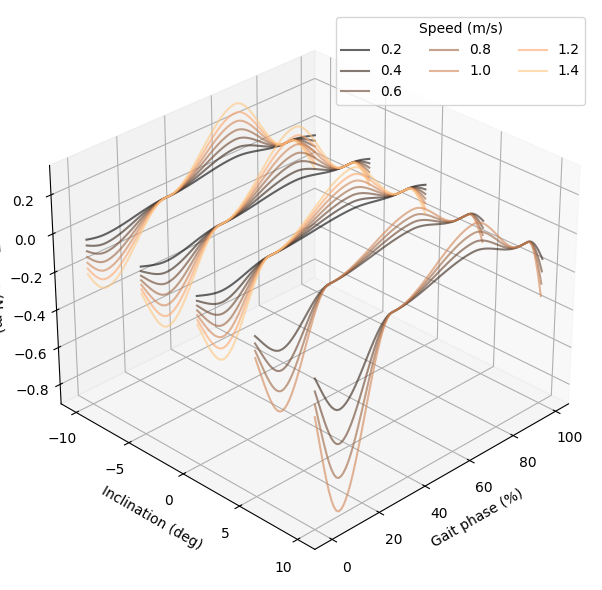

In [26]:
num_speeds = len(speeds_val)
colormap = cm.get_cmap('copper', num_speeds)
speed_colors = {}
for i in range(num_speeds):
    rgba = colormap(i)
    speed_colors[speeds_val[i]] = rgba

plt.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts for editable PDF text
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

for i, inclination in enumerate(inclinations_val):
    print(inclination)
    for j, speed in enumerate(speeds_val):
        if torque_splines[inclination][speed] is None:
            continue
        
        # Convert inclination label to numeric value
        z = float(inclinations_val[i])
        
        x = np.arange(len(torque_splines[inclination][speed]))
        y = torque_splines[inclination][speed]
        
        # Create an array of z values for each point
        z_values = np.array([z] * len(x))
        
        # Get the color for the current speed
        color = speed_colors[speed]
        
        # Plot the data, interchanging y and z_values
        if inclination == 0:
            # Only add label for the first occurrence of each speed (at LG/0 inclination)
            ax.plot(x, z_values, y, color=color, label=f'{speed}', alpha=0.6)
        else:
            ax.plot(x, z_values, y, color=color, alpha=0.6)
            
ax.set_xlabel('Gait phase (%)')
ax.set_zlabel('Torque (N-m)')
ax.set_ylabel('Inclination (deg)')
ax.set_yticks(inclinations_val)
ax.grid(True)
ax.legend(ncol=3, title = "Speed (m/s)", loc='upper right')

ax.view_init(elev=30, azim=45)
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('torque_splines_3D.pdf', dpi=700)  # Save before showing
plt.show()


In [ ]:
# Export avg_hip_moment as a pickle file
with open('torque_splines.pkl', 'wb') as f:
    pickle.dump(torque_splines, f)

with open('torque_splines.pkl', 'rb') as f:
    loaded_torque_splines = pickle.load(f)